In [1]:
#Đỗ Ngọc Lâm - B22DCCN476

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [2]:
#Đỗ Ngọc Lâm - B22DCCN476

df = pd.read_csv("behavior_train_150_rows.csv")

df.head()

,qty_laptop_cart,qty_mobile_cart,spent_laptop_cart,spent_mobile_cart,orders_with_laptop,orders_with_mobile,spent_laptop_orders,spent_mobile_orders,has_both_in_cart,has_mixed_order,days_since_customer_created,recency_laptop,recency_mobile,label
0,1,1,20744935,7475626,2,3,39647598,18746010,1,1,451,60,59,both
1,5,1,94398990,11282653,0,0,0,0,1,0,567,37,51,both
2,3,3,55546170,30800925,2,0,51588214,0,1,0,95,69,54,both
3,5,3,76231230,33185688,0,2,0,14336290,1,0,539,50,41,both
4,1,1,21800533,11130859,2,3,30304366,24216039,1,1,189,82,1,both


In [3]:
#Đỗ Ngọc Lâm - B22DCCN476

print(df.shape)
df.info()
df.describe()

(150, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   qty_laptop_cart              150 non-null    int64 
 1   qty_mobile_cart              150 non-null    int64 
 2   spent_laptop_cart            150 non-null    int64 
 3   spent_mobile_cart            150 non-null    int64 
 4   orders_with_laptop           150 non-null    int64 
 5   orders_with_mobile           150 non-null    int64 
 6   spent_laptop_orders          150 non-null    int64 
 7   spent_mobile_orders          150 non-null    int64 
 8   has_both_in_cart             150 non-null    int64 
 9   has_mixed_order              150 non-null    int64 
 10  days_since_customer_created  150 non-null    int64 
 11  recency_laptop               150 non-null    int64 
 12  recency_mobile               150 non-null    int64 
 13  label                    

,qty_laptop_cart,qty_mobile_cart,spent_laptop_cart,spent_mobile_cart,orders_with_laptop,orders_with_mobile,spent_laptop_orders,spent_mobile_orders,has_both_in_cart,has_mixed_order,days_since_customer_created,recency_laptop,recency_mobile
count,150.000000,150.000000,1.500000e+02,1.500000e+02,150.000000,150.000000,1.500000e+02,1.500000e+02,150.000000,150.000000,150.000000,150.000000,150.000000
mean,2.246667,2.666667,4.184233e+07,2.228261e+07,1.086667,1.353333,2.057502e+07,1.271677e+07,0.673333,0.420000,429.513333,43.373333,46.560000
std,1.779588,1.834299,3.495299e+07,1.664355e+07,1.104820,1.204782,2.130203e+07,1.199075e+07,0.470565,0.495212,220.178504,24.425354,26.452307
min,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,35.000000,1.000000,1.000000
25%,1.000000,1.000000,1.594436e+07,7.291904e+06,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,275.250000,23.250000,22.250000
50%,2.000000,3.000000,3.807201e+07,2.214825e+07,1.000000,1.000000,1.747669e+07,1.095844e+07,1.000000,0.000000,430.500000,44.500000,51.000000
75%,4.000000,4.000000,6.844573e+07,3.396172e+07,2.000000,3.000000,3.549709e+07,2.273640e+07,1.000000,1.000000,615.750000,61.000000,69.750000
max,5.000000,5.000000,1.248820e+08,5.838323e+07,3.000000,3.000000,7.279991e+07,3.892225e+07,1.000000,1.000000,799.000000,90.000000,90.000000


In [4]:
#Đỗ Ngọc Lâm - B22DCCN476

label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["label"])

print(label_encoder.classes_)
df.head()

['both' 'laptop' 'mobile']


,qty_laptop_cart,qty_mobile_cart,spent_laptop_cart,spent_mobile_cart,orders_with_laptop,orders_with_mobile,spent_laptop_orders,spent_mobile_orders,has_both_in_cart,has_mixed_order,days_since_customer_created,recency_laptop,recency_mobile,label
0,1,1,20744935,7475626,2,3,39647598,18746010,1,1,451,60,59,0
1,5,1,94398990,11282653,0,0,0,0,1,0,567,37,51,0
2,3,3,55546170,30800925,2,0,51588214,0,1,0,95,69,54,0
3,5,3,76231230,33185688,0,2,0,14336290,1,0,539,50,41,0
4,1,1,21800533,11130859,2,3,30304366,24216039,1,1,189,82,1,0


In [5]:
#Đỗ Ngọc Lâm - B22DCCN476

X = df.drop("label", axis=1)
y = df["label"]

print(X.shape)
print(y.shape)

(150, 13)
(150,)


In [15]:
#Đỗ Ngọc Lâm - B22DCCN476

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [7]:
#Đỗ Ngọc Lâm - B22DCCN476

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)

(120, 13)


In [8]:
#Đỗ Ngọc Lâm - B22DCCN476

model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.3),

    Dense(32, activation="relu"),
    Dropout(0.2),

    Dense(3, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                896       
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_2 (Dense)             (None, 3)                 99        
                                                                 
Total params: 3075 (12.01 KB)
Trainable params: 3075 (12.01 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [9]:
#Đỗ Ngọc Lâm - B22DCCN476

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/50


6/6 [==============================] - 2s 80ms/step - loss: 1.4929 - accuracy: 0.1979 - val_loss: 1.3323 - val_accuracy: 0.1667
Epoch 2/50
6/6 [==============================] - 0s 22ms/step - loss: 1.2530 - accuracy: 0.2708 - val_loss: 1.1496 - val_accuracy: 0.1667
Epoch 3/50
6/6 [==============================] - 0s 19ms/step - loss: 1.0674 - accuracy: 0.4271 - val_loss: 0.9965 - val_accuracy: 0.2917
Epoch 4/50
6/6 [==============================] - 0s 23ms/step - loss: 0.9905 - accuracy: 0.4167 - val_loss: 0.8668 - val_accuracy: 0.6250
Epoch 5/50
6/6 [==============================] - 0s 18ms/step - loss: 0.8346 - accuracy: 0.6979 - val_loss: 0.7609 - val_accuracy: 0.8333
Epoch 6/50
6/6 [==============================] - 0s 15ms/step - loss: 0.7077 - accuracy: 0.7812 - val_loss: 0.6678 - val_accuracy: 0.8750
Epoch 7/50
6/6 [==============================] - 0s 15ms/step - loss: 0.6243 - accuracy: 0.8229 - val_loss: 0.5860 - val_accuracy: 0.8750
Epoch 8/50
6/6 [=========

In [10]:
#Đỗ Ngọc Lâm - B22DCCN476

loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy:", accuracy)

1/1 [==============================] - 0s 37ms/step - loss: 0.0097 - accuracy: 1.0000
Accuracy: 1.0


In [11]:
#Đỗ Ngọc Lâm - B22DCCN476

predictions = model.predict(X_test)

pred_classes = np.argmax(predictions, axis=1)

print(classification_report(y_test, pred_classes))

1/1 [==============================] - 0s 121ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         7

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [12]:
#Đỗ Ngọc Lâm - B22DCCN476

model.save("model_behavior.h5")

print("Model saved!")

Model saved!


C:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [13]:
#Đỗ Ngọc Lâm - B22DCCN476

import pickle

pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(label_encoder, open("label_encoder.pkl", "wb"))

print("Scaler & Encoder saved!")

Scaler & Encoder saved!


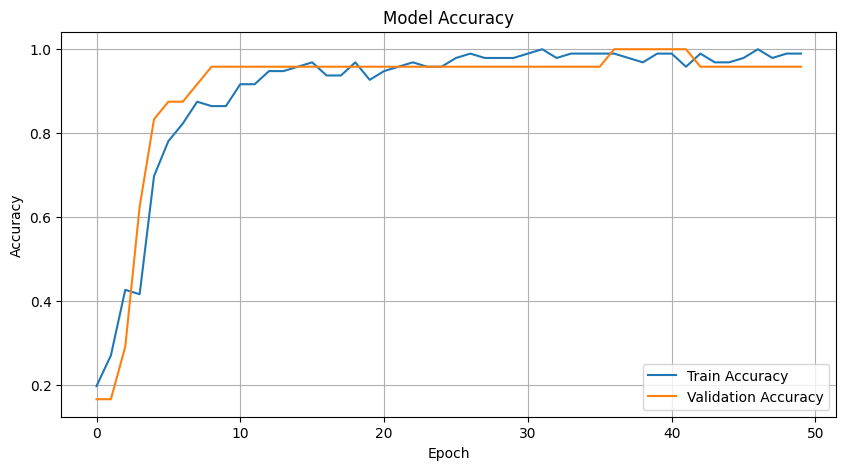

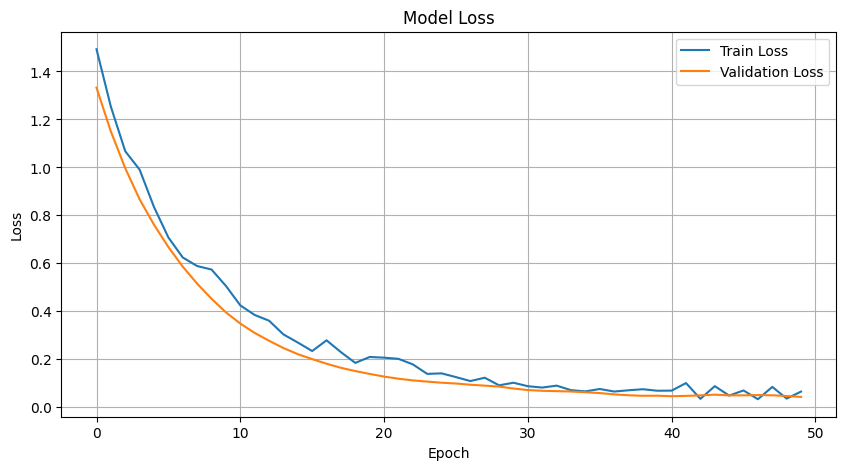

In [14]:
#Đỗ Ngọc Lâm - B22DCCN476

import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()


# Loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()